# Problem Statement

XYZ Co's 2014-2018 sales data to identify key revenue and profit drivers across products,channels and regions, Uncover seasonal trends and 
outliers and align performance against budgets. Use these insights to optimize pricing,, promotions and market expansion for sustainable growth and reduced concentration risk.

In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

sheets = pd.read_excel(
    'E:\\C DATA\\Users\\Dell\\Desktop\\Jyoti\\Sales-Analysis-main\\Regional Sales Dataset.xlsx',
    sheet_name=None
)

In [4]:
# Assign dataframes to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']

In [5]:
print("df_sales: ", (df_sales.shape))
print("df_customers:",(df_customers.shape))
print("df_products: ",(df_products.shape))
print("df_regions: ", (df_regions.shape))
print("df_state_reg: ", (df_state_reg.shape))
print("df_budgets: ", (df_budgets.shape))

df_sales:  (64104, 12)
df_customers: (175, 2)
df_products:  (30, 2)
df_regions:  (994, 15)
df_state_reg:  (49, 3)
df_budgets:  (30, 2)


In [6]:
df_sales.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [7]:
df_customers.head(5)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [8]:
df_products.head(5)

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [9]:
df_regions.head(5)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [10]:
df_state_reg.head(5)


,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [11]:
df_budgets.head(5)

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [12]:
new_header = df_state_reg.iloc[0]
df_state_reg.columns = new_header
df_state_reg = df_state_reg[1:].reset_index(drop=True)

df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [13]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [14]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [15]:
df_state_reg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [16]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [17]:
df_budgets.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

# Data Cleaning and wrangling  (data modleing or joing tables)

In [18]:
# Merge with customers

df = df_sales.merge(
    df_customers,
    how='left',
    left_on = 'Customer Name Index',
    right_on = 'Customer Index'
)

In [19]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [20]:
# Merge with products

df = df.merge(
    df_products,
    how='left',
    left_on = 'Product Description Index',
    right_on = 'Index'
)

In [21]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [22]:
# Merge with Regions

df = df.merge(
    df_regions,
    how='left',
    left_on = 'Delivery Region Index',
    right_on = 'id'
)

In [23]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [24]:
# Merge with State Regions

df = df.merge(
    df_state_reg[["State Code","Region"]],
    how='left',
    left_on = 'state_code',
    right_on = 'State Code'
)

In [25]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [26]:
# merge with Budgets

df = df.merge(
    df_budgets,
    how='left',
    on= 'Product Name'
)


In [27]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [28]:
import os
print(os.path.expanduser("~/Desktop"))

C:\Users\Dell/Desktop


In [29]:
import os

folder = r'C:\Users\Dell\Desktop\Sales_Project'

os.makedirs(folder, exist_ok=True)

df.to_csv(os.path.join(folder, 'file.csv'), index=False)

In [30]:
df.to_csv(r'C:\Users\Dell\Desktop\Sales_Project\file.csv', index=False)

In [31]:
import os

folder = r'C:\Users\Dell\Desktop\Sales_Project'
print(os.path.exists(folder))

True


In [32]:
import os

print(os.path.exists(r'C:\Users\Dell\Desktop\Sales_Project\sales_data.csv'))

True


In [33]:
import os

print(os.listdir(r'C:\Users\Dell\Desktop\Sales_Project'))

['file.csv', 'final.csv', 'sales_data.csv']


In [34]:
import os

os.startfile(r'C:\Users\Dell\Desktop\Sales_Project')

In [35]:
# Customer Index
# Index
# id
# State Code

# clean up redundant columns

cols_to_drop = ['Customer Index', 'Index', 'id', 'State Code']
df = df.drop(columns = cols_to_drop,errors = 'ignore')

df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [36]:
# convert all columns to lower case for consistency and easier accesse

df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [37]:
#KEEP THE IMPORTANT COLUMNS AND DELETE TEH COLUMNS THAT WE DON'T NEED

cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'
    
]

In [38]:
df = df[cols_to_keep]

In [39]:
df.head(5)

,ordernumber,orderdate,customer names,channel,product name,order quantity,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [40]:
# Rename the columns

df =df.rename(columns={
    'ordernumber': 'order_number',
    'orderdate': 'order_date',
    'customer names': 'customer_name',
    'product name': 'product_name',
    'order quantity':'order_quantity',
    'unit price': 'unit_price',
    'line total': 'revenue',
    'total_unit_cost': 'cost',
    'state_code' : 'state',
    'state': 'state_name',
    'latitude': 'lat',
    'longitude': 'lon',
    '2017 budgets': 'budget'
})

df.head(1)

,order_number,order_date,customer_name,channel,product_name,order_quantity,revenue,total unit cost,state,county,state_name,region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231


In [41]:
# Blank out budgets for non- 2017 orders

df.loc[df['order_date'].dt.year != 2017,'budget'] = pd.NA

# Line total is revenue
df[['order_date','product_name','revenue','budget']].tail(5)

,order_date,product_name,revenue,budget
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN
64103,2018-02-28,Product 15,7986.4,NaN


In [42]:
df.to_csv(r'C:\Users\Dell\Desktop\Sales_Project\final.csv', index=False)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   customer_name    64104 non-null  object        
 3   channel          64104 non-null  object        
 4   product_name     64104 non-null  object        
 5   order_quantity   64104 non-null  int64         
 6   revenue          64104 non-null  float64       
 7   total unit cost  64104 non-null  float64       
 8   state            64104 non-null  object        
 9   county           64104 non-null  object        
 10  state_name       64104 non-null  object        
 11  region           64104 non-null  object        
 12  lat              64104 non-null  float64       
 13  lon              64104 non-null  float64       
 14  budget           15263 non-null  float

In [44]:
## Filter the dataset to inlude only records from the year 2017

df_2017 = df[df['order_date'].dt.year == 2017]

In [45]:
df.isnull().sum()

order_number           0
order_date             0
customer_name          0
channel                0
product_name           0
order_quantity         0
revenue                0
total unit cost        0
state                  0
county                 0
state_name             0
region                 0
lat                    0
lon                    0
budget             48841
dtype: int64

In [46]:
df_2017.head(3)

,order_number,order_date,customer_name,channel,product_name,order_quantity,revenue,total unit cost,state,county,state_name,region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315


In [47]:
df['total_cost'] = df['order_quantity'] * df['total unit cost']

In [48]:
df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = df['profit'] / df['revenue']*100

In [49]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,revenue,total unit cost,state,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


# Exploratory Analysis

## 🔹 1. *Monthly Sales Trend Over Time*

Goal: Track revenue trends over time to detect seasonality or sales spikes

Chart: Line chart

EDA Type: Temporal (time series)

Structure: Line with markers to highlight monthly revenue points clearly

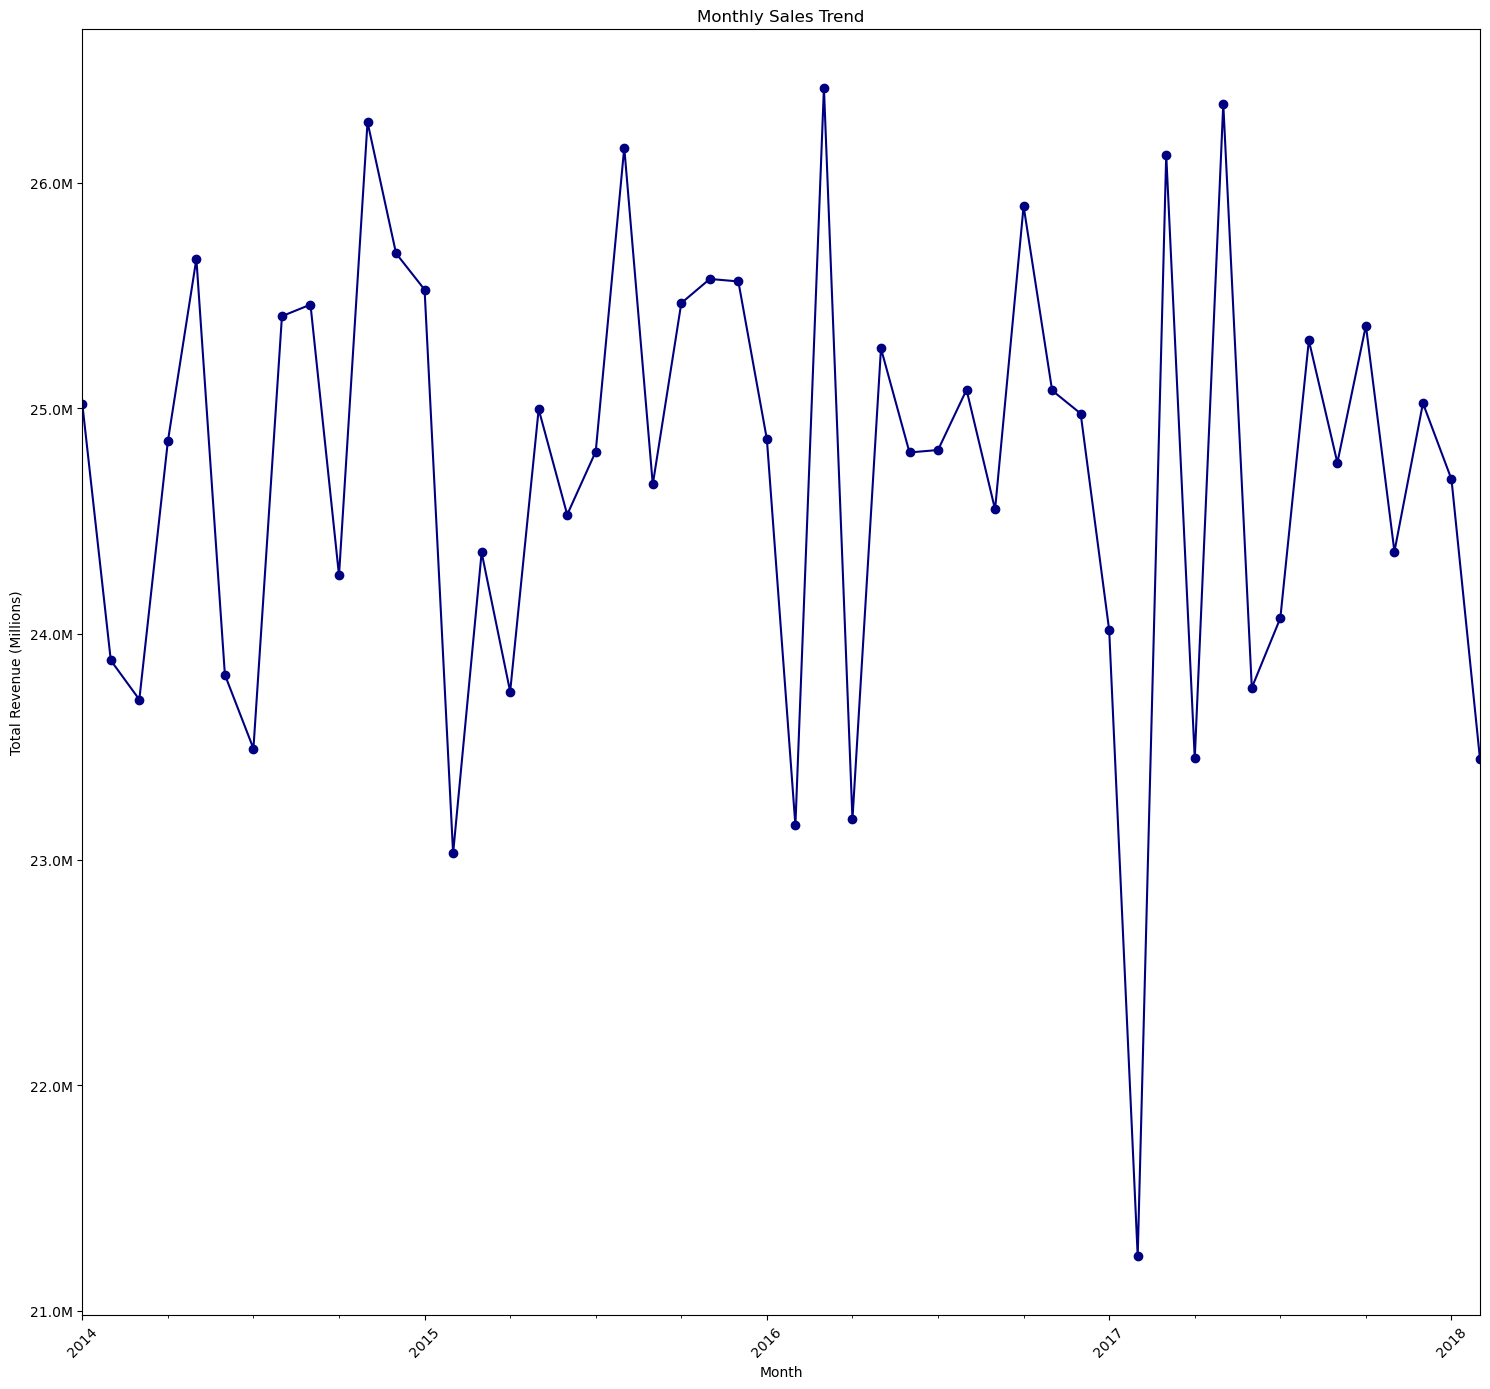

In [50]:
df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(15,14))

monthly_sales.plot(marker='o', color='navy')

from matplotlib.ticker import FuncFormatter

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### INSIGHTS ---
Sales consistently cycle between \$24 M and \$26 M, with clear peaks in late spring to early summer (May–June) and troughs each January.  

The overall trend remains stable year over year, reflecting a reliable seasonal demand pattern.  

However, the sharp revenue drop in early 2017 stands out as an outlier, warranting closer investigation into potential causes such as market disruptions or mistimed promotions.  

## 🔹 2. *Monthly Sales Trend (All Years Combined)*

Goal: Highlight overall seasonality patterns by aggregating sales across all years for each calendar month

Chart: Line chart

EDA Type: Temporal (time series)

Structure: Line with markers, months ordered January to December based on month number

In [51]:
# Assuming df is your Dataframe
# Convert order_date to datetime (if not already)

df['order_date'] = pd.to_datetime(df['order_date'])

# Remove records from january and February 2018

df_new = df[~((df['order_date'].dt.year == 2018) & (df['order_date'].dt.month.isin([1,2])))]

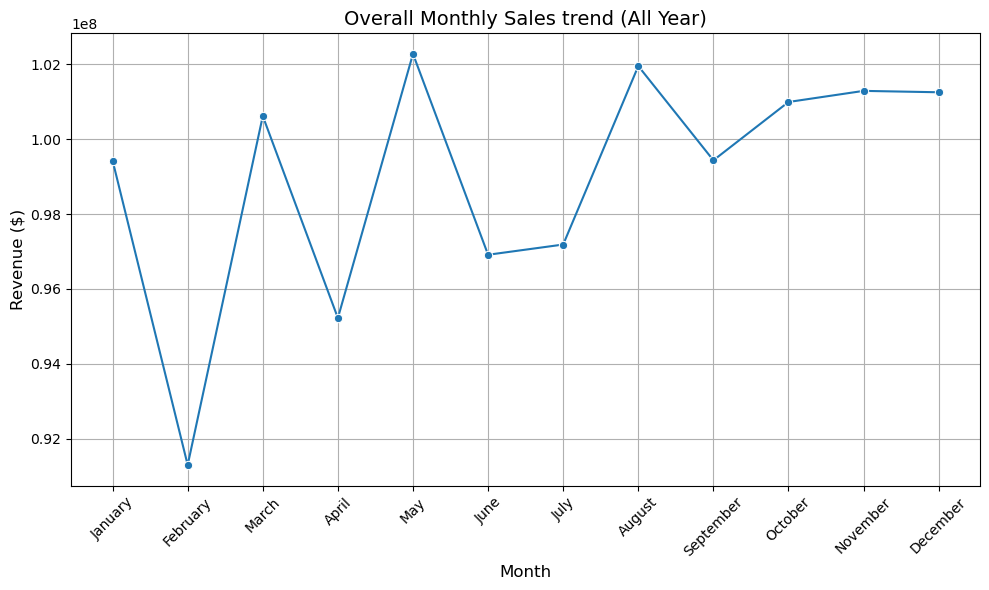

In [52]:
# Make a copy
df_new = df_new.copy()
#  Assuming df is your Dataframe
# Convert order_date to datetime

df_new['order_date'] = pd.to_datetime(df_new['order_date'])

#Extract month name for grouping
df_new['month'] = df_new['order_date'].dt.strftime('%B')

#Agrregate revenue by month across all years

monthly_trend = df_new.groupby('month')['revenue'].sum().reset_index()

# sort months in calendar order

month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

monthly_trend['month'] = pd.Categorical(monthly_trend['month'], categories=month_order, ordered=True)
monthly_trend = monthly_trend.sort_values('month')

# Create the line chart

plt.figure(figsize=(10,6))
sns.lineplot(data = monthly_trend, x='month', y='revenue', marker='o')
plt.title('Overall Monthly Sales trend (All Year)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize= 12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### INSIGHTS ---

Across all years, January begins strong with roughly \$99 M, followed by a steep decline through April’s low point (≈\$95 M).

Sales rebound in May and August (≈\$102 M) before settling into a plateau of \$99–101 M from September to December.

This pattern reveals a strong post–New Year surge, a spring dip, and a mid–summer bump each calendar year.


## 🔹 3. *Top 10 Products by Revenue (in Millions)*

Goal: Identify the highest-grossing products to focus marketing and inventory efforts

Chart: Horizontal bar chart

EDA Type: Univariate

Structure: Bars sorted descending to show top 10 products with revenue scaled in millions

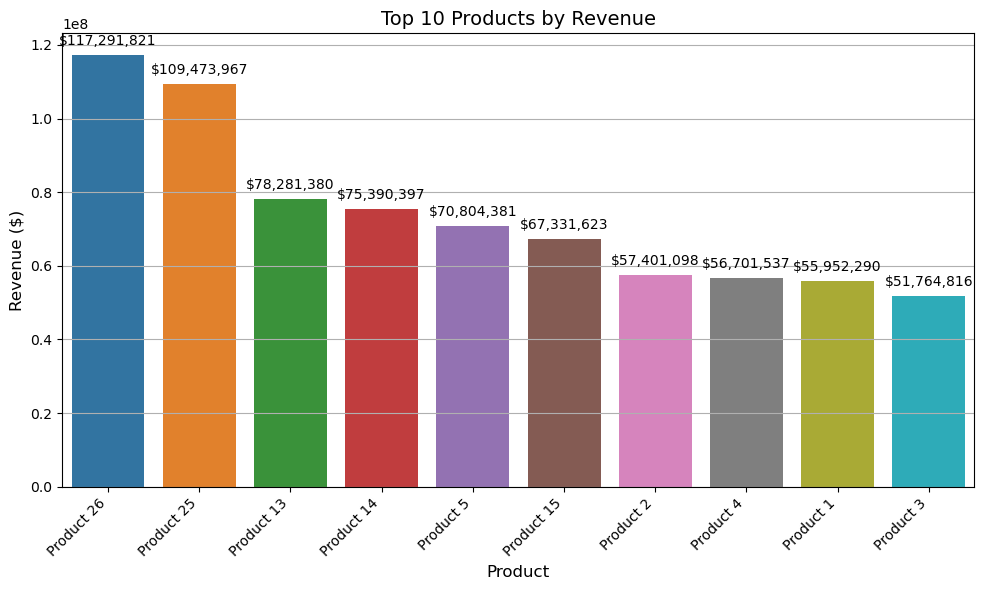

In [53]:
product_revenue = df.groupby('product_name')['revenue'].sum().reset_index()

# Get top 10 products by revenue
top_10_products = product_revenue.sort_values(by='revenue', ascending=False).head(10)

# Create the bar chart

plt.figure(figsize=(10,6))
barplot = sns.barplot(data=top_10_products, x='product_name', y='revenue', hue='product_name', palette='tab10')

# Add labels on top of each ba

for p in barplot.patches:
    barplot.annotate(f'${p.get_height():,.0f}',
                     (p.get_x() +p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black',
                     xytext=(0,5), textcoords='offset points')

plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()

plt.show()

### INSIGHTS ---
Products 26 and 25 pull away at \$118 M and \$110 M, with a sharp drop to \$78 M for Product 13 and a tight mid-pack at \$68–\$75 M.  

The bottom four cluster at \$52–\$57 M, highlighting similar constraints.  

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.  

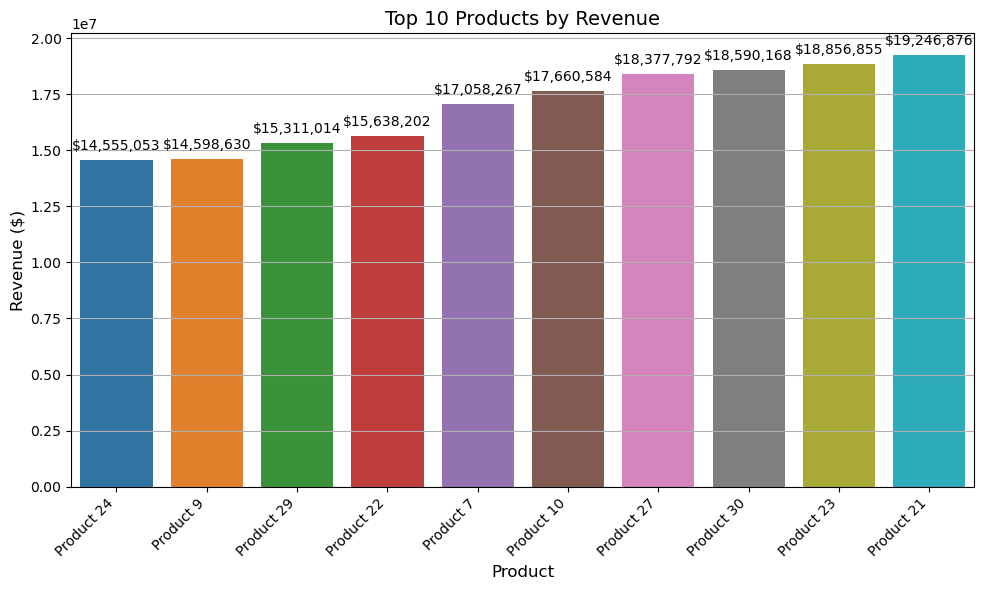

In [54]:
product_revenue = df.groupby('product_name')['revenue'].sum().reset_index()

# Get bottom  10 products by revenue
top_10_products = product_revenue.sort_values(by='revenue', ascending=True).head(10)

# Create the bar chart

plt.figure(figsize=(10,6))
barplot = sns.barplot(data=top_10_products, x='product_name', y='revenue', hue='product_name', palette='tab10')

# Add labels on top of each ba

for p in barplot.patches:
    barplot.annotate(f'${p.get_height():,.0f}',
                     (p.get_x() +p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black',
                     xytext=(0,5), textcoords='offset points')

plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()

plt.show()

## 🔹 4. *Sales by Channel (Pie Chart)*

Goal: Show distribution of total sales across channels to identify dominant sales routes

Chart: Pie chart

EDA Type: Univariate

Structure: Pie segments with percentage labels, colors for clarity, start angle adjusted

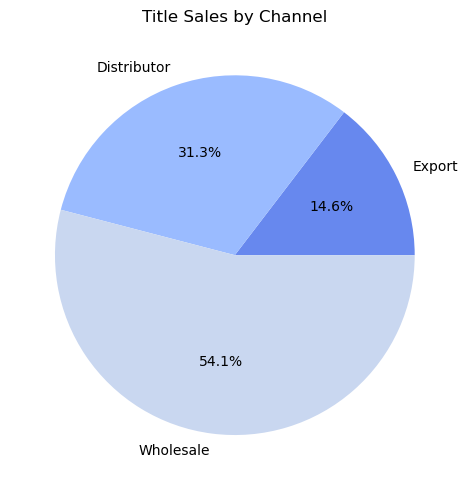

In [55]:
## Sales By channel

chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(5,5))

plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm')
)

plt.title('Title Sales by Channel')
plt.tight_layout()
plt.show()


### INSIGHTS ---
Wholesale accounts for 54 % of sales, with distributors at ~31 % and exports at ~15 %, underscoring reliance on domestic bulk channels.  

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives—through targeted overseas marketing and strategic partner relationships.  


## 🔹 5. *Average Order Value (AOV) Distribution*

Goal: Understand distribution of order values to identify typical spending levels and outliers

Chart: Histogram

EDA Type: Univariate

Structure: Histogram with 50 bins, colored bars with edge highlights to show frequency of order values

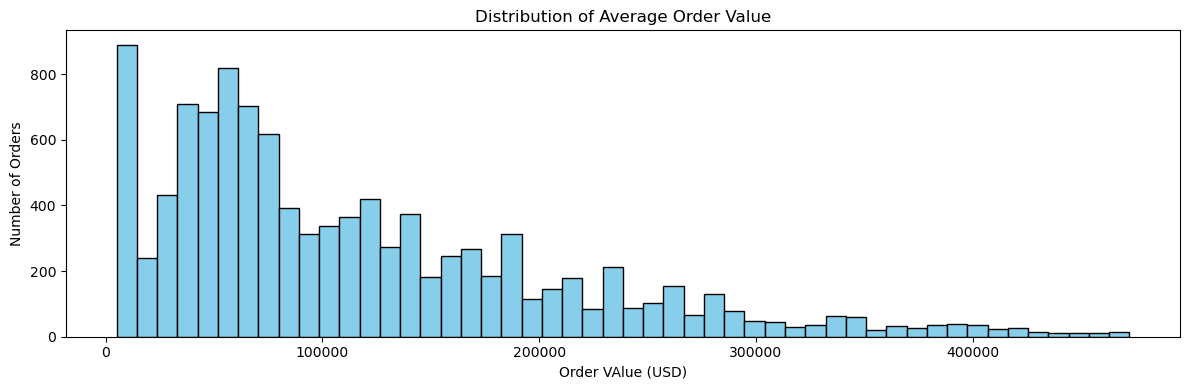

In [56]:
## Average Order VAlue AOV) Distribution

aov = df.groupby('order_number')['revenue'].sum()
plt.figure(figsize=(12,4))

plt.hist(
    aov,
    bins=50,
    color = 'skyblue',
    edgecolor='black'
)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order VAlue (USD)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

### INSIGHTS ---
The order‐value distribution is heavily right‐skewed, with most orders clustering between \$20 K and \$120 K and a pronounced mode around \$50 K–\$60 K.  

A long tail of high-value transactions extends up toward \$400 K–\$500 K, but these large orders represent only a small share of total volume.  


## 🔹 6. *Unit Price Distribution per Product*

Goal: Compare pricing variability across different products to identify price consistency and outliers

Chart: Boxplot

EDA Type: Bivariate

Structure: Boxplot with rotated labels to display unit price spread per product

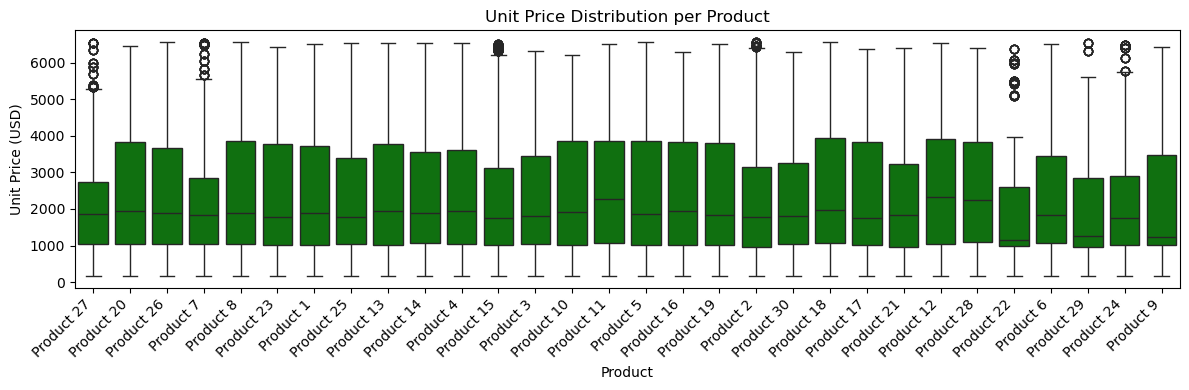

In [98]:
# Set figure size for clarity
plt.figure(figsize=(12,4))

# Create a boxplot of unit_price by product_name
sns.boxplot(
    data=df,
    x='product_name',   # X-axis: product categories
    y='unit_price',      # Y-axis: unit price values
    color='g'            # Box color
)

# Add title and axis labels
plt.title('Unit Price Distribution per Product')  # Chart title
plt.xlabel('Product')                              # X-axis label
plt.ylabel('Unit Price (USD)')                     # Y-axis label

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

### INSIGHTS ---
Products 8, 17, 27, 20, and 28 show high-end revenue spikes—well above their upper whiskers—likely due to bulk orders, special-edition releases, or premium bundles that temporarily inflate earnings.  

In contrast, deep low-end outliers (near \$0–\$100) on Products 20 and 27 suggest promotional giveaways or test SKUs that pull down average prices.  

To ensure accurate margin and pricing assessments, exclude these outlier transactions from average calculations.  

Then assess whether such anomalies warrant formalization as ongoing promotional strategies or should be phased out to stabilize pricing performance.


# 7.  Unit Price Distribution for Top 10 Products by Revenue

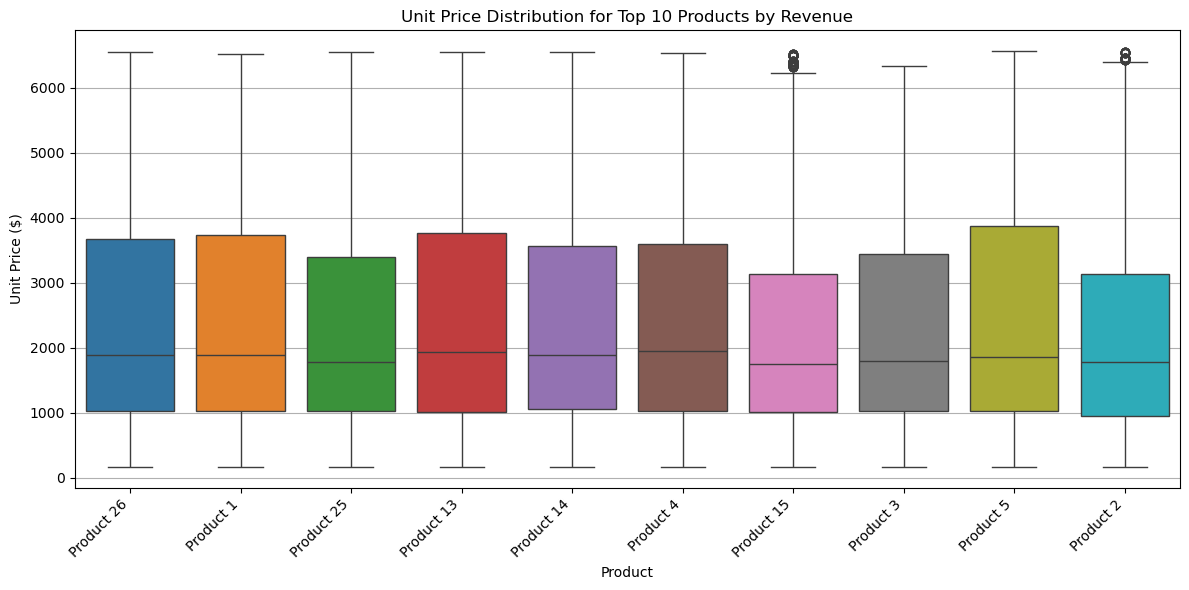

In [64]:
# Create unit_price
df['unit_price'] = df['revenue'] / df['order_quantity']

# Top 10 products
product_revenue = df.groupby('product_name')['revenue'].sum().reset_index()

top_10_product = (
    product_revenue
    .sort_values(by='revenue', ascending=False)
    .head(10)['product_name']
    .tolist()
)

df_top_10 = df[df['product_name'].isin(top_10_product)]

# Boxplot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_top_10,
    x='product_name',
    y='unit_price',
    hue='product_name',
    palette='tab10',
    legend=False
)

plt.title('Unit Price Distribution for Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Unit Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## 🔹 8. *Top 10 States by Revenue and Order Count*

Goal: Identify highest revenue-generating states and compare their order volumes

Chart: Two bar charts

EDA Type: Multivariate

Structure: First chart shows top 10 states by revenue (in millions), second shows top 10 states by number of orders

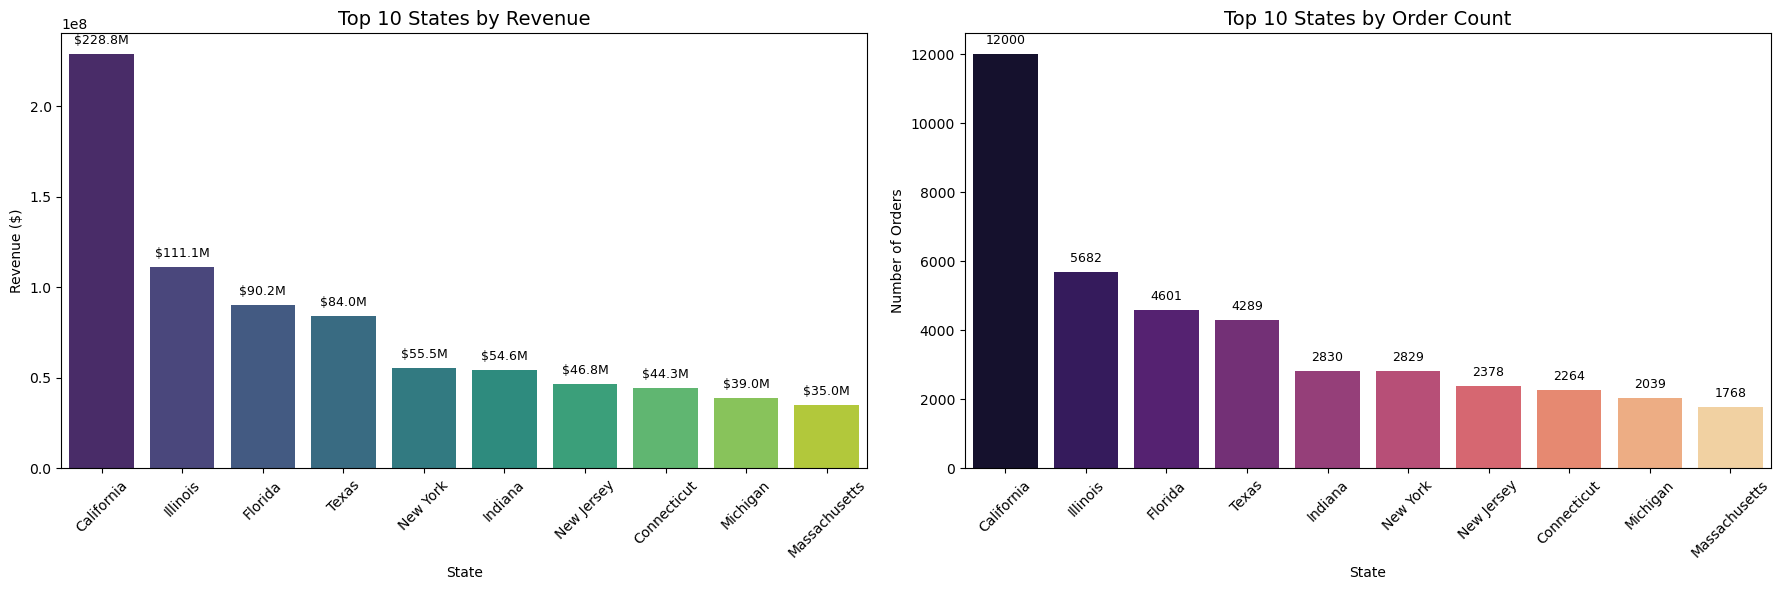

In [69]:
# Top 10 States by Revenue and Order Count
# Top 10 States by Revenue

state_revenue = (
    df.groupby('state_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

# Top 10 States by Order Count
state_orders = (
    df.groupby('state_name')['order_number']
      .count()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# ---------------- Revenue Chart ----------------
bar1 = sns.barplot(
    data=state_revenue,
    x='state_name',
    y='revenue',
    hue='state_name',
    palette='viridis',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Top 10 States by Revenue', fontsize=14)
axes[0].set_xlabel('State')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

# Revenue Labels
for p in bar1.patches:
    axes[0].annotate(
        f'${p.get_height()/1e6:.1f}M',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        color='black',
        xytext=(0,5),
        textcoords='offset points'
    )

# ---------------- Order Count Chart ----------------
bar2 = sns.barplot(
    data=state_orders,
    x='state_name',
    y='order_number',
    hue='state_name',
    palette='magma',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Top 10 States by Order Count', fontsize=14)
axes[1].set_xlabel('State')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

# Order Count Labels
for p in bar2.patches:
    axes[1].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        color='black',
        xytext=(0,5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

In [76]:
df.head(1)

,order_number,order_date,customer_name,channel,product_name,order_quantity,revenue,total unit cost,state,county,...,region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month,unit_price,profit_margin
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,14994.6,1824.343,GA,Chatham County,...,South,32.08354,-81.09983,NaN,10946.058,13170.257,27.0,2014-01,2499.1,87.833333


## 🔹 12. *Average Profit Margin by Channel*

Goal: Compare average profit margins across sales channels to identify the most and least profitable routes

Chart: Bar chart

EDA Type: Bivariate

Structure: Vertical bars with data labels showing margin percentages, sorted descending by channel

In [74]:
avg_profit_margin = (
    df.groupby('channel')['profit_margin_pct']
      .mean()
      .reset_index()
)

print(avg_profit_margin)

       channel  profit_margin_pct
0  Distributor          37.557091
1       Export          37.932704
2    Wholesale          37.087236


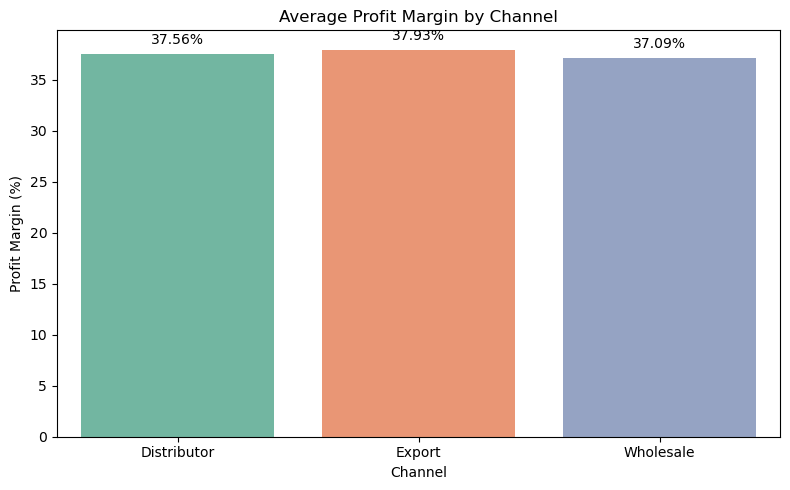

In [75]:
plt.figure(figsize=(8,5))

barplot = sns.barplot(
    data=avg_profit_margin,
    x='channel',
    y='profit_margin_pct',
    hue='channel',
    palette='Set2',
    legend=False
)

for p in barplot.patches:
    barplot.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0,5),
        textcoords='offset points'
    )

plt.title("Average Profit Margin by Channel")
plt.xlabel("Channel")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

### INSIGHTS ---
Export leads with a 37.93 % average margin, closely followed by Distributor (37.56 %) and Wholesale (37.09 %).  

The tiny spread (<0.2 %) shows consistently strong profitability across all channels.  

This uniformity implies well-controlled costs and pricing power everywhere.  

To maximize returns, push volume growth in Export while maintaining efficiency in Distributor and Wholesale.  

## 🔹 11. *Top 10 States by Revenue and Order Count*

Goal: Identify highest revenue-generating states and compare their order volumes

Chart: Two bar charts

EDA Type: Multivariate

Structure: First chart shows top 10 states by revenue (in millions), second shows top 10 states by number of orders

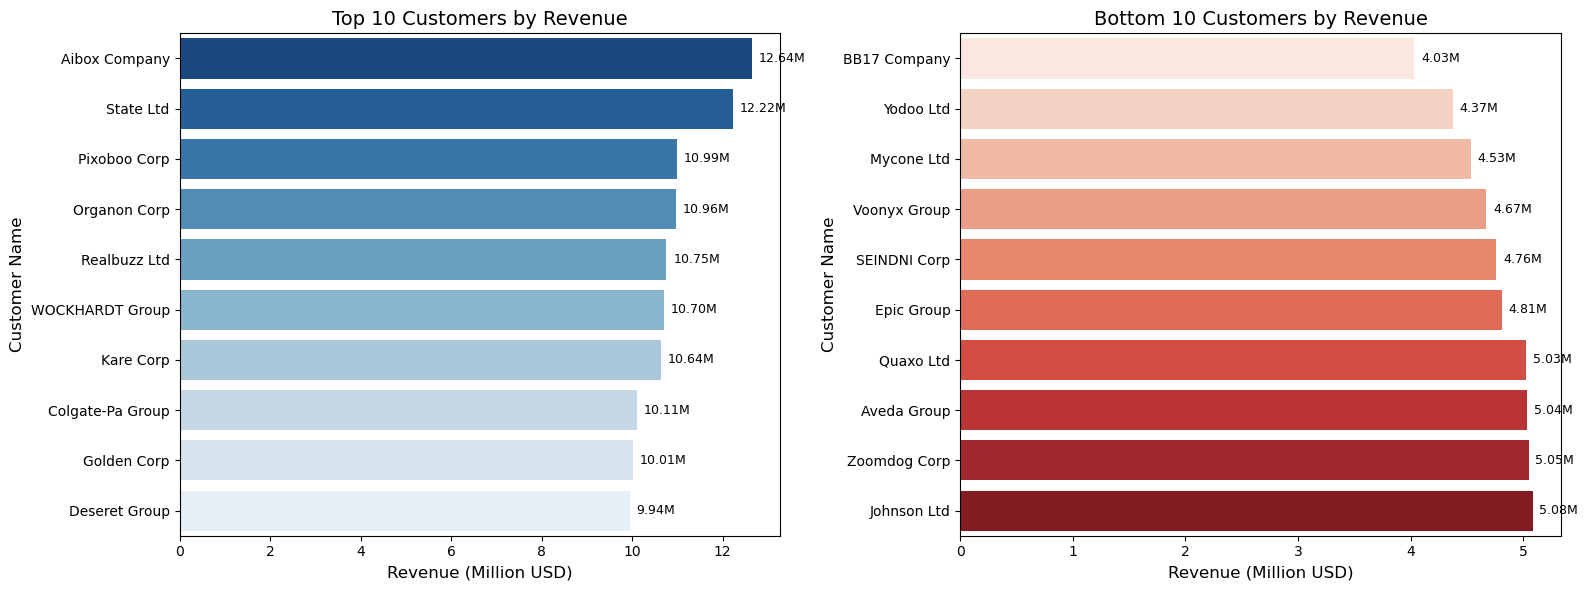

In [87]:
# Top 10 Customers by Revenue
top_rev = (
    df.groupby('customer_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Bottom 10 Customers by Revenue
bottom_rev = (
    df.groupby('customer_name')['revenue']
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------- Top 10 ----------------
bar1 = sns.barplot(
    x=top_rev.values / 1e6,
    y=top_rev.index,
    hue=top_rev.index,
    palette='Blues_r',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Top 10 Customers by Revenue', fontsize=14)
axes[0].set_xlabel('Revenue (Million USD)', fontsize=12)
axes[0].set_ylabel('Customer Name', fontsize=12)

# Revenue Labels
for p in bar1.patches:
    axes[0].annotate(
        f'{p.get_width():.2f}M',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=9,
        xytext=(5, 0),
        textcoords='offset points'
    )

# ---------------- Bottom 10 ----------------
bar2 = sns.barplot(
    x=bottom_rev.values / 1e6,
    y=bottom_rev.index,
    hue=bottom_rev.index,
    palette='Reds',
    legend=False,
    ax=axes[1]
)

axes[1].set_title('Bottom 10 Customers by Revenue', fontsize=14)
axes[1].set_xlabel('Revenue (Million USD)', fontsize=12)
axes[1].set_ylabel('Customer Name', fontsize=12)

# Revenue Labels
for p in bar2.patches:
    axes[1].annotate(
        f'{p.get_width():.2f}M',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=9,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

### INSIGHTS ---
- Aibox Company tops the list with \$12.5 M, followed closely by State Ltd (\$12.2 M), while the 10th-ranked Deseret Group still contributes \$9.9 M—demonstrating a tight \$10–12 M top tier.

- At the bottom, Johnson Ltd leads its group with \$5.1 M, down to BB17 Company at \$4.1 M—roughly half the top customer’s revenue.

- This steep drop from ~\$10 M+ to \$4–5 M highlights high revenue concentration among the top customers.

- Action: prioritize retention and upsell for your top ten, and launch targeted growth campaigns to elevate the lower-revenue cohort.


## 🔹 14. *Customer Segmentation: Revenue vs. Profit Margin*

Goal: Segment customers by total revenue and average profit margin, highlighting order volume

Chart: Bubble chart (scatter plot with variable point sizes)

EDA Type: Multivariate

Structure: Scatter points sized by number of orders, plotting revenue vs. margin

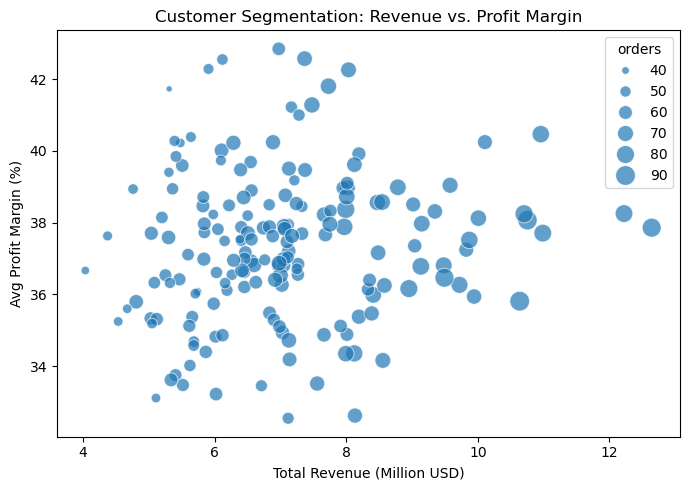

In [88]:
# Aggregate metrics per customer
cust_summary = df.groupby('customer_name').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin_pct', 'mean'),
    orders=('order_number', 'nunique')
)

# Convert revenue to millions
cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

plt.figure(figsize=(7, 5))

# Bubble chart with revenue in millions
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',        # <-- use revenue in millions
    y='avg_margin',
    size='orders',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin')
plt.xlabel('Total Revenue (Million USD)')  # <-- updated label
plt.ylabel('Avg Profit Margin (%)')

plt.tight_layout()
plt.show()


### INSIGHTS ---

- Customers with >\$10 M in revenue tend to sustain margins between 36–40%, indicating that scale does not significantly erode profitability.
- Most customers cluster within the \$6–10 M range and show stable margins (~34–40%), suggesting consistent pricing in this tier.
- Customers below \$6 M display the widest margin variance (~33–43%), pointing to more volatile cost structures or discounts among smaller accounts.
- Bubble size (order count) increases with revenue, but margin levels appear unaffected—reinforcing revenue as the dominant performance driver over order volume.


## 🔹 15. *Correlation Heatmap of Numeric Features*

Goal: Identify relationships among key numeric variables to uncover potential multicollinearity

Chart: Correlation heatmap

EDA Type: Multivariate

Structure: Annotated heatmap with correlation coefficients for selected numeric columns

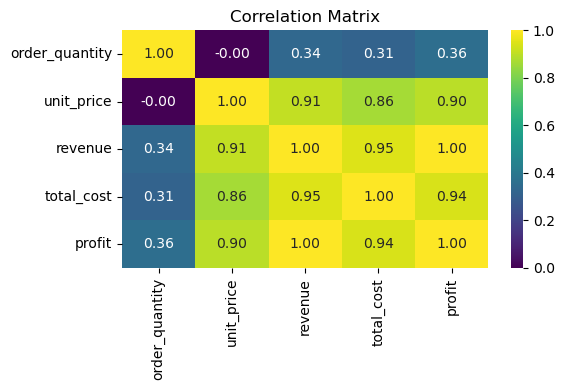

In [90]:
# List numeric columns to include in the correlation calculation
num_cols = ['order_quantity', 'unit_price', 'revenue', 'total_cost', 'profit']

# Calculate the correlation matrix for these numeric features
corr = df[num_cols].corr()

# Set the figure size for clarity
plt.figure(figsize=(6,4))

# Plot the heatmap with annotations and a viridis colormap
sns.heatmap(
    corr,           # Data: correlation matrix
    annot=True,     # Display the correlation coefficients on the heatmap
    fmt=".2f",      # Format numbers to two decimal places
    cmap='viridis'  # Color palette for the heatmap
)

# Add title for context
plt.title('Correlation Matrix')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the heatmap
plt.show()

### INSIGHTS ---
- **Profit and revenue** are very strongly correlated (0.87), indicating that as sales value increases, profit tends to rise as well.  
- **Unit price** is a key driver: it correlates 0.91 with revenue, 0.79 with profit, and 0.94 with cost—highlighting how pricing decisions ripple through both top‑line and expense figures.  
- **Cost** shows a strong link to revenue (0.85) but a more moderate tie to profit (0.58), underscoring that while higher sales often bring higher expenses, margins can still vary.  
- **Quantity** has virtually no correlation with unit price or cost (≈0.00) and only modest associations with revenue (0.34) and profit (0.30), making volume a secondary factor compared to pricing.  


## 🔹 9. *Total Sales by US Region*

**Goal:** Compare total sales across U.S. regions to identify top‑performing markets and areas for targeted growth.

**Chart:** Horizontal bar chart

**EDA Type:** Univariate comparison

**Structure:**  
- Bars sorted ascending (Northeast → West) for clear bottom‑to‑top ranking  
- X‑axis in millions USD, Y‑axis listing regions  


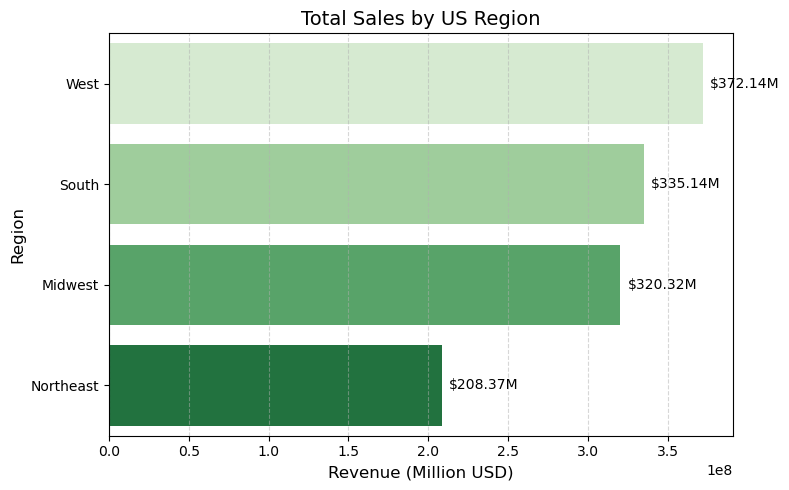

In [99]:
# Total Sales by Region
region_sales = (
    df.groupby('region')['revenue']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

barplot = sns.barplot(
    data=region_sales,
    x='revenue',
    y='region',
    hue='region',
    palette='Greens',
    legend=False
)

# Add Revenue Labels
for p in barplot.patches:
    barplot.annotate(
        f'${p.get_width()/1e6:.2f}M',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=10,
        xytext=(5,0),
        textcoords='offset points'
    )

plt.title('Total Sales by US Region', fontsize=14)
plt.xlabel('Revenue (Million USD)', fontsize=12)
plt.ylabel('Region', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### INSIGHTS —  
- **West dominates** with roughly \$360 M in sales (~35 % of total), underscoring its market leadership.  
- **South & Midwest** each contribute over \$320 M (~32 %), indicating strong, consistent demand across central regions.  
- **Northeast trails** at about \$210 M (~20 %), signaling room for growth and targeted investment.  
- **Action:** Focus on closing the Northeast gap with local promotions and strategic partnerships, while maintaining national playbook success.  


## 🔹 7. *Profit Margin % vs. Unit Price*

Goal: Examine relationship between unit price and profit margin percentage across orders

Chart: Scatter plot

EDA Type: Bivariate

Structure: Scatter points with transparency to show data density

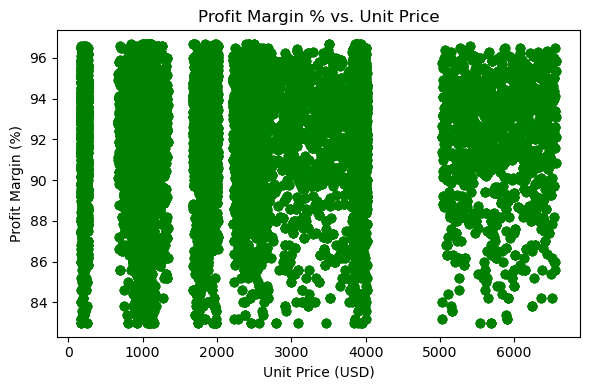

In [96]:
# Profit MArgin % vs. Unit price

# Calculate profit margin percentage for each record
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

# Set the figure size for clarity
plt.figure(figsize=(6,4))

# Plot unit price vs. profit margin percentage
plt.scatter(
    df['unit_price'],            # X-axis: unit price in USD
    df['profit_margin_pct'],     # Y-axis: profit margin percentage
    alpha=0.6,                   # Transparency level for overlapping points
    color='green'                # Point color
)

# Add title and axis labels
plt.title('Profit Margin % vs. Unit Price')  # Chart title
plt.xlabel('Unit Price (USD)')                # X-axis label
plt.ylabel('Profit Margin (%)')               # Y-axis label

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

### INSIGHTS ---

Profit margins are concentrated between ~18% and 60%, with no clear correlation to unit price, which spans from near \$0 to over \$6,500.

Dense horizontal bands indicate consistent margin tiers across a wide price spectrum, reflecting uniform pricing strategies.

Outliers below 18% at both low and high price points may signal cost inefficiencies or pricing issues worth deeper investigation.
